# Análisis Univariado del Dataset Stablecoins

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("../data/stablecoins.csv")

In [24]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [25]:
df.head()

,price,market_cap,datetime,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,stablecoin,stablecoin_id
0,1.002412,110105.0,2017-12-06,0.002412,0.0,0.0,0.001469,USDT,1
1,1.001515,110105.0,2017-12-07,0.001515,0.0,0.0,0.000907,USDT,1
2,0.999473,110105.0,2017-12-08,0.000527,0.0,0.0,0.001506,USDT,1
3,0.999584,110105.0,2017-12-09,0.000416,0.0,0.0,0.001148,USDT,1
4,1.000546,110105.0,2017-12-10,0.000546,0.0,0.0,0.000590,USDT,1


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21575 entries, 0 to 21574
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   price                21575 non-null  float64       
 1   market_cap           21575 non-null  float64       
 2   datetime             21575 non-null  datetime64[us]
 3   peg_deviation        21575 non-null  float64       
 4   supply_change_1d     21575 non-null  float64       
 5   supply_change_7d     21575 non-null  float64       
 6   price_volatility_3d  21575 non-null  float64       
 7   stablecoin           21575 non-null  str           
 8   stablecoin_id        21575 non-null  int64         
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 1.6 MB


In [27]:
df.describe()

,price,market_cap,datetime,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,stablecoin_id
count,21575.000000,2.157500e+04,21575,2.157500e+04,21575.000000,21575.000000,21575.000000,21575.000000
mean,0.999960,1.546335e+10,2023-02-24 21:19:12.834299,1.004683e-03,0.015162,0.105373,0.001139,5.267856
min,0.942000,1.101050e+05,2017-12-06 00:00:00,2.155425e-07,-0.861513,-0.871983,0.000009,1.000000
25%,0.999194,1.322493e+08,2021-08-29 00:00:00,3.848583e-04,-0.002293,-0.010045,0.000639,2.000000
50%,0.999998,6.929045e+08,2023-03-23 00:00:00,8.073728e-04,0.000087,0.000986,0.001003,5.000000
75%,1.000808,6.569135e+09,2024-11-11 00:00:00,1.388404e-03,0.003631,0.019541,0.001432,8.000000
max,1.005042,1.902405e+11,2026-07-04 00:00:00,5.800000e-02,272.800618,272.800618,0.034778,10.000000
std,0.001893,3.468685e+10,NaN,1.604504e-03,1.859014,4.916832,0.001514,2.931759


In [28]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
price,21575.0,0.99996,0.942,0.999194,0.999998,1.000808,1.005042,0.001893
market_cap,21575.0,15463352928.621065,110105.0,132249348.5,692904504.0,6569135313.5,190240489246.0,34686846579.419357
datetime,21575,2023-02-24 21:19:12.834299,2017-12-06 00:00:00,2021-08-29 00:00:00,2023-03-23 00:00:00,2024-11-11 00:00:00,2026-07-04 00:00:00,NaN
peg_deviation,21575.0,0.001005,0.0,0.000385,0.000807,0.001388,0.058,0.001605
supply_change_1d,21575.0,0.015162,-0.861513,-0.002293,0.000087,0.003631,272.800618,1.859014
supply_change_7d,21575.0,0.105373,-0.871983,-0.010045,0.000986,0.019541,272.800618,4.916832
price_volatility_3d,21575.0,0.001139,0.000009,0.000639,0.001003,0.001432,0.034778,0.001514
stablecoin_id,21575.0,5.267856,1.0,2.0,5.0,8.0,10.0,2.931759


# Variable: Stablecoin

Tipo

Variable categórica.

Contiene 10 stablecoins diferentes.

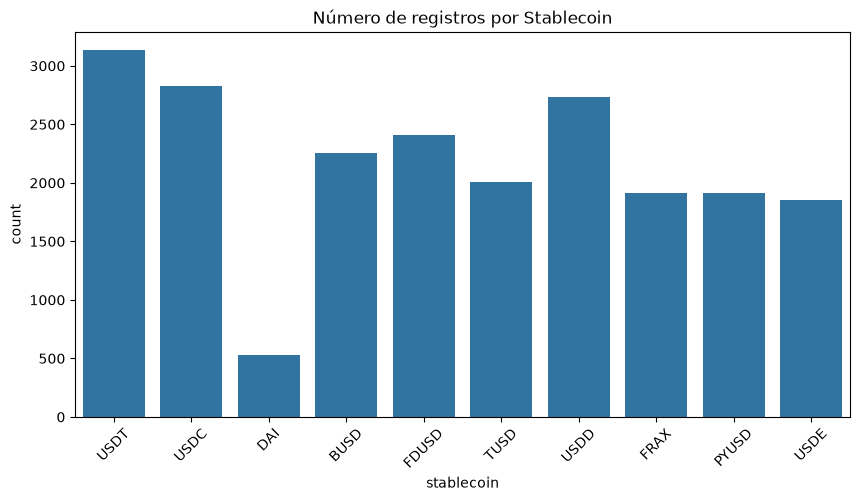

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="stablecoin")
plt.xticks(rotation=45)
plt.title("Número de registros por Stablecoin")
plt.show()

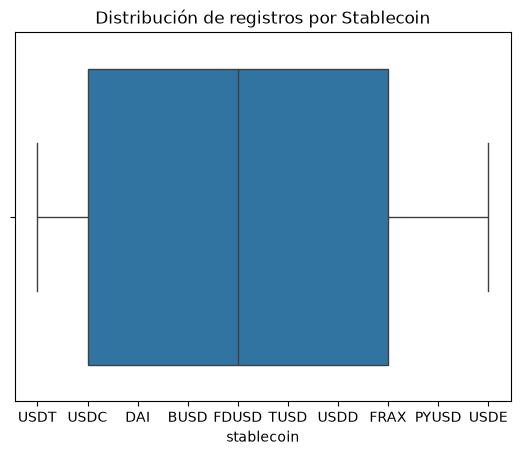

In [30]:
sns.boxplot(x=df["stablecoin"])
plt.title("Distribución de registros por Stablecoin")
plt.show()

Interpretación

El conjunto de datos incluye información histórica de diez stablecoins diferentes. La distribución de registros es bastante equilibrada, aunque algunas monedas disponen de un mayor historial temporal que otras. Esto permite realizar comparaciones entre activos sin un sesgo importante.

# Variable Price

Representa el precio diario de cada stablecoin.

Estadísticos principales

Media: 0.99996 USD

Mediana: 0.999998 USD

Mínimo: 0.942 USD

Máximo: 1.005 USD


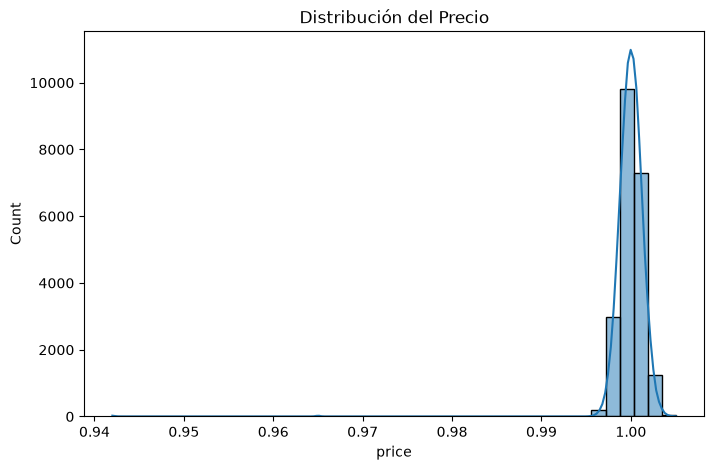

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribución del Precio")
plt.show()

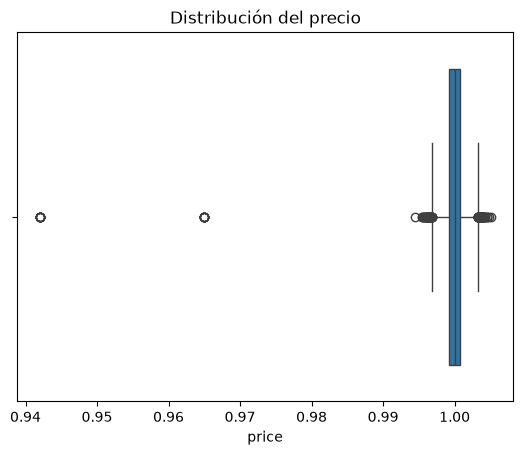

In [32]:
sns.boxplot(x=df["price"])
plt.title("Distribución del precio")
plt.show()

Interpretación

La mayor parte de las observaciones se concentran alrededor del valor de 1 dólar, comportamiento esperado en una stablecoin. Sin embargo, existen algunas desviaciones importantes, alcanzando mínimos cercanos a 0.94 USD, lo que evidencia episodios de pérdida temporal del peg (depeg).

# Variable Market Cap

Representa la capitalización de mercado.

Estadísticos

Media: 15,46 mil millones USD

Máximo: 190 mil millones USD

In [9]:
df["market_cap"].describe()

count    2.157500e+04
mean     1.546335e+10
std      3.468685e+10
min      1.101050e+05
25%      1.322493e+08
50%      6.929045e+08
75%      6.569135e+09
max      1.902405e+11
Name: market_cap, dtype: float64

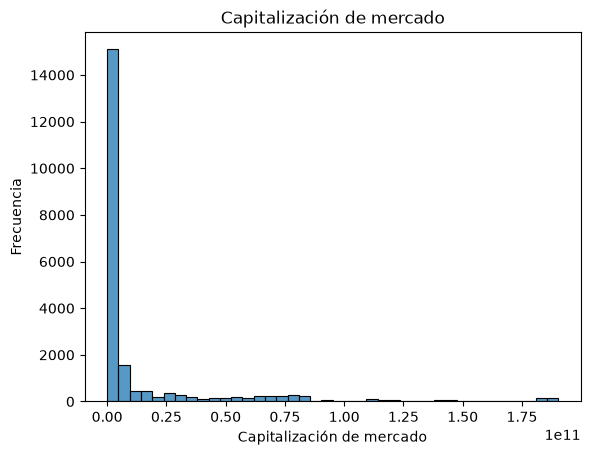

In [ ]:
sns.histplot(df["market_cap"], bins=40)
plt.title("Capitalización de mercado")
plt.xlabel("Capitalización de mercado")
plt.ylabel("Frecuencia")
plt.show()

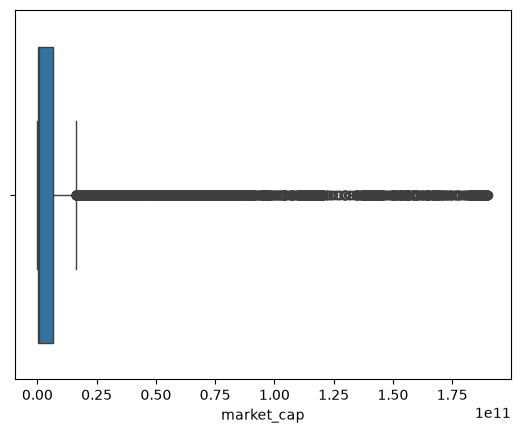

In [35]:
sns.boxplot(x=df["market_cap"])
plt.show()

Interpretación

La distribución presenta una fuerte asimetría positiva. La mayoría de las stablecoins poseen una capitalización relativamente baja, mientras que unas pocas, como USDT o USDC, concentran gran parte del mercado. Los valores extremos son esperables y representan diferencias reales en el tamaño de estos activos.

# Variable Peg Deviation

Mide la distancia entre el precio real y el valor objetivo de 1 USD.



Estadísticos

Media: 0.0010

Máximo: 0.058

In [12]:
df["peg_deviation"].describe()

count    2.157500e+04
mean     1.004683e-03
std      1.604504e-03
min      2.155425e-07
25%      3.848583e-04
50%      8.073728e-04
75%      1.388404e-03
max      5.800000e-02
Name: peg_deviation, dtype: float64

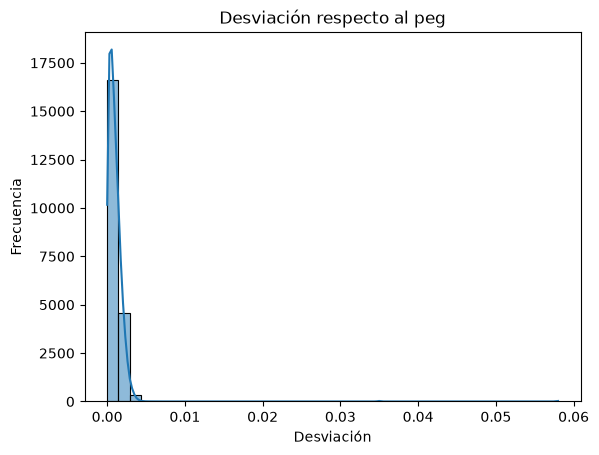

In [36]:
sns.histplot(df["peg_deviation"], bins=40, kde=True)
plt.title("Desviación respecto al peg")
plt.xlabel("Desviación")
plt.ylabel("Frecuencia")
plt.show()

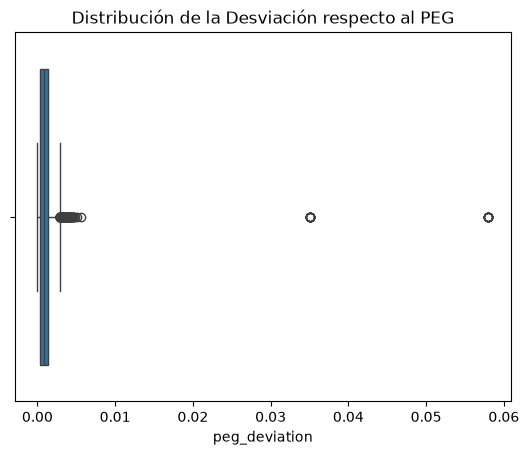

In [37]:
sns.boxplot(x=df["peg_deviation"])
plt.title("Distribución de la Desviación respecto al PEG")
plt.show()

Interpretación

La mayoría de los registros muestran desviaciones muy pequeñas respecto al peg, lo que indica un funcionamiento estable del mercado. Sin embargo, aparecen algunos valores extremos que representan episodios de pérdida temporal de estabilidad, aspecto fundamental dentro de este proyecto.

# Variable: Supply Change 1D

Representa el crecimiento diario de la oferta.

Estadísticos

Media: 0.015 %

Máximo: 272.8 %

In [43]:
df["supply_change_1d"].describe()

count    21575.000000
mean         0.015162
std          1.859014
min         -0.861513
25%         -0.002293
50%          0.000087
75%          0.003631
max        272.800618
Name: supply_change_1d, dtype: float64

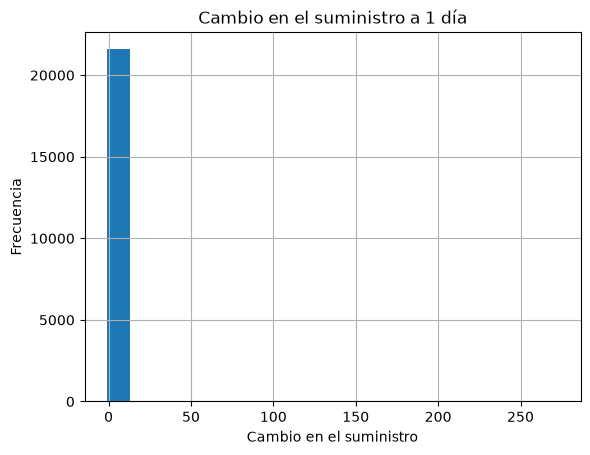

In [42]:
df["supply_change_1d"].hist(bins=20)
plt.title("Cambio en el suministro a 1 día")
plt.xlabel("Cambio en el suministro")
plt.ylabel("Frecuencia")
plt.show()

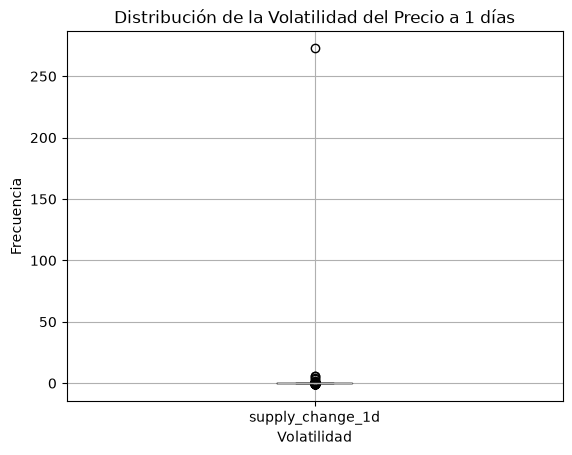

In [47]:
df.boxplot(column="supply_change_1d")    
plt.title("Distribución de la Volatilidad del Precio a 1 días")
plt.xlabel("Volatilidad")
plt.ylabel("Frecuencia")
plt.show()

Interpretación

La mayoría de los cambios diarios son pequeños, aunque existen incrementos extraordinarios que pueden corresponder a emisiones masivas o eventos excepcionales. La distribución presenta una fuerte asimetría positiva y numerosos valores atípicos.

# Variable: Supply Change 7D

Representa la variación semanal de la oferta.

In [48]:
df["supply_change_7d"].describe()

count    21575.000000
mean         0.105373
std          4.916832
min         -0.871983
25%         -0.010045
50%          0.000986
75%          0.019541
max        272.800618
Name: supply_change_7d, dtype: float64

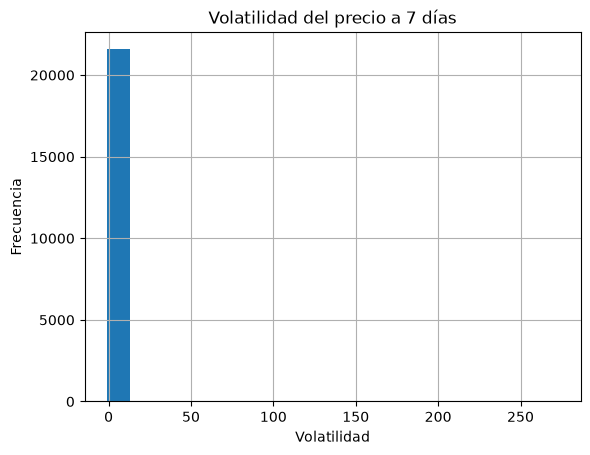

In [49]:
df["supply_change_7d"].hist(bins=20)
plt.title("Volatilidad del precio a 7 días")
plt.xlabel("Volatilidad")
plt.ylabel("Frecuencia")
plt.show()

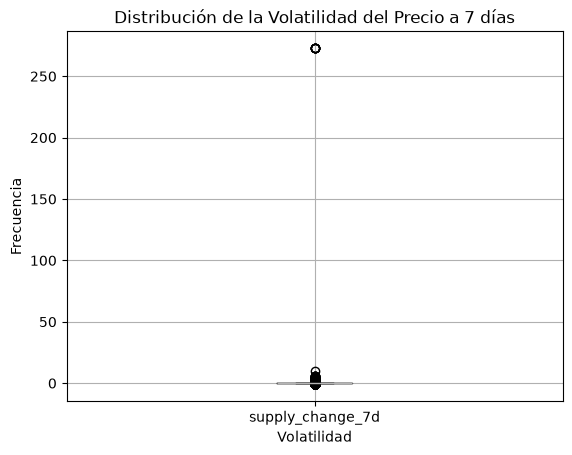

In [50]:
df.boxplot(column="supply_change_7d")    
plt.title("Distribución de la Volatilidad del Precio a 7 días")
plt.xlabel("Volatilidad")
plt.ylabel("Frecuencia")
plt.show()

Interpretación

El comportamiento es similar al observado en el cambio diario, aunque con una mayor dispersión. Las variaciones semanales permiten identificar tendencias de crecimiento o reducción sostenida en la emisión de stablecoins.

# Variable: Price Volatility 3D

Mide la volatilidad del precio durante tres días.

Estadísticos

Media: 0.00114

Máximo: 0.0348




In [44]:
df["price_volatility_3d"].describe()

count    21575.000000
mean         0.001139
std          0.001514
min          0.000009
25%          0.000639
50%          0.001003
75%          0.001432
max          0.034778
Name: price_volatility_3d, dtype: float64

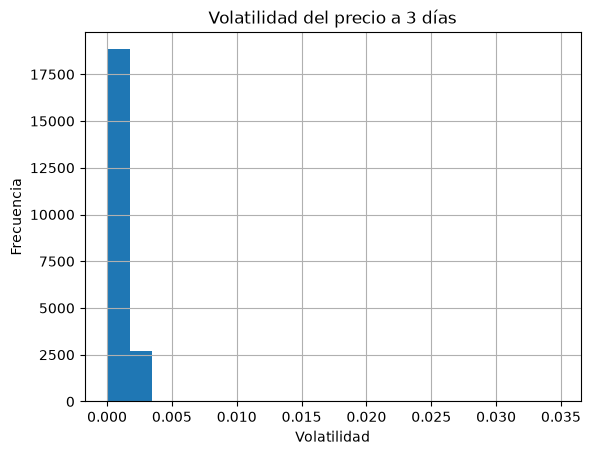

In [45]:
df["price_volatility_3d"].hist(bins=20)
plt.title("Volatilidad del precio a 3 días")
plt.xlabel("Volatilidad")
plt.ylabel("Frecuencia")
plt.show()

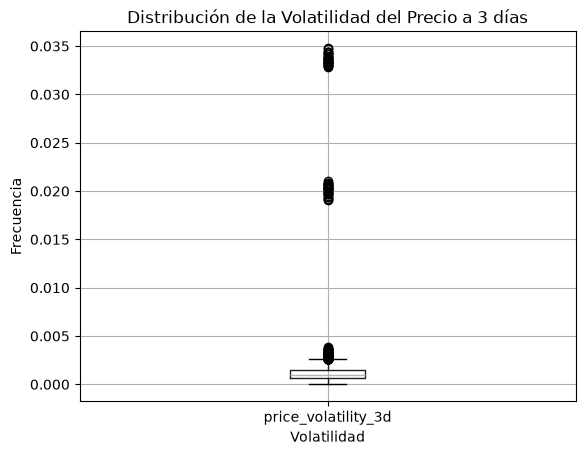

In [40]:
df.boxplot(column="price_volatility_3d")    
plt.title("Distribución de la Volatilidad del Precio a 3 días")
plt.xlabel("Volatilidad")
plt.ylabel("Frecuencia")
plt.show()

Interpretación

La volatilidad es generalmente baja, lo cual es consistente con el objetivo principal de una stablecoin: mantener un precio estable. No obstante, algunos periodos muestran incrementos significativos de volatilidad asociados a eventos de mercado o posibles depegs.

# Conclusión del análisis univariado

El análisis univariado evidencia que el conjunto de datos posee una buena calidad, sin valores faltantes y con variables adecuadamente estructuradas para su análisis. El precio de las stablecoins se mantiene, en la mayoría de las observaciones, muy próximo al valor de referencia de 1 USD, confirmando el comportamiento esperado de este tipo de activos. Sin embargo, se identifican desviaciones puntuales del peg y valores atípicos en variables como la capitalización de mercado, los cambios en la oferta y la volatilidad, lo que refleja episodios de tensión o movimientos excepcionales del mercado. Estos resultados constituyen una base sólida para las siguientes etapas del proyecto, como el análisis bivariado, la detección de anomalías mediante Isolation Forest y la construcción del cuadro de mando en Power BI.